Importing Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error, depolarizing_error, ReadoutError

Building a Simple Quantum Circuit

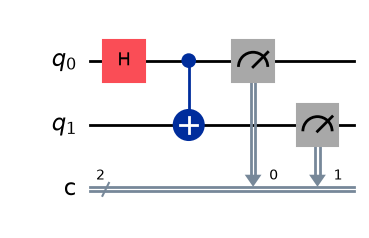

In [2]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw('mpl')

Creating the Noise Model

In [3]:
# Relaxation times (s) and gate durations (s)
t1 = 50e-6
t2 = 70e-6
gate_time_1q = 50e-9
gate_time_2q = 2e-6

# 1. Single-qubit errors ('h')
thermal_1q = thermal_relaxation_error(t1, t2, gate_time_1q)
depol_1q = depolarizing_error(0.001, 1)
h_error = thermal_1q.compose(depol_1q)

# 2. Two-qubit errors ('cx')
thermal_single = thermal_relaxation_error(t1, t2, gate_time_2q)
thermal_2q = thermal_single.expand(thermal_single)
depol_2q = depolarizing_error(0.01, 2)
cx_error = thermal_2q.compose(depol_2q)

# 3. Readout error (Capitalized Class)
p0given1 = 0.03
p1given0 = 0.01
ro_error = ReadoutError([[1 - p1given0, p1given0], [p0given1, 1 - p0given1]])

# Assemble Noise Model
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(h_error, ['h'])
noise_model.add_all_qubit_quantum_error(cx_error, ['cx'])
noise_model.add_all_qubit_readout_error(ro_error)

Running Ideal and Noisy Simulations

In [4]:
# Ideal simulation (no noise)
ideal_sim = AerSimulator()
ideal_job = ideal_sim.run(transpile(qc, ideal_sim), shots=1000)
ideal_counts = ideal_job.result().get_counts()

# Noisy simulation
noisy_sim = AerSimulator(noise_model=noise_model)
noisy_job = noisy_sim.run(transpile(qc, noisy_sim), shots=1000)
noisy_counts = noisy_job.result().get_counts()

print("Ideal counts:", ideal_counts)
print("Noisy counts:", noisy_counts)

Ideal counts: {'11': 474, '00': 526}
Noisy counts: {'01': 30, '11': 438, '00': 493, '10': 39}


Visualizing the Comparison

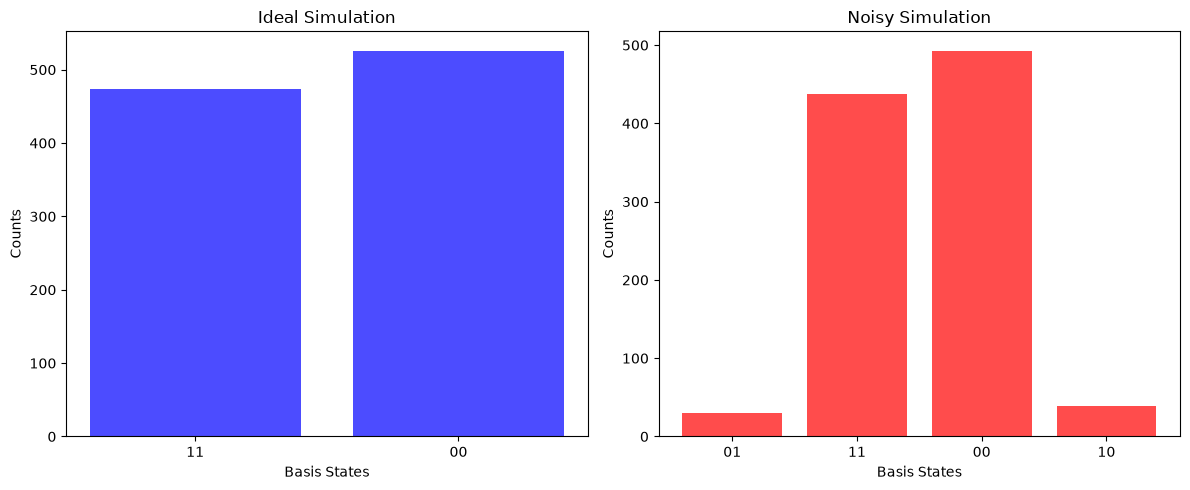

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(ideal_counts.keys(), ideal_counts.values(), color='blue', alpha=0.7)
ax1.set_title('Ideal Simulation')
ax1.set_xlabel('Basis States')
ax1.set_ylabel('Counts')
ax2.bar(noisy_counts.keys(), noisy_counts.values(), color='red', alpha=0.7)
ax2.set_title('Noisy Simulation')
ax2.set_xlabel('Basis States')
ax2.set_ylabel('Counts')
plt.tight_layout()
plt.show()

The Noise Model You Can Extend

In [6]:
single_depol = depolarizing_error(0.02, 1)
noise_model.add_all_qubit_quantum_error(single_depol, ['h', 'x', 'y', 'z'])